C:\Users\user\AppData\Local\Temp\ipykernel_50316\3457821362.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, conn)
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_50316\3457821362.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  max_customer['Cluster'] = 3
C:\Users\user\AppData\Local\Temp\ipykernel_50316\3457821362.py:79

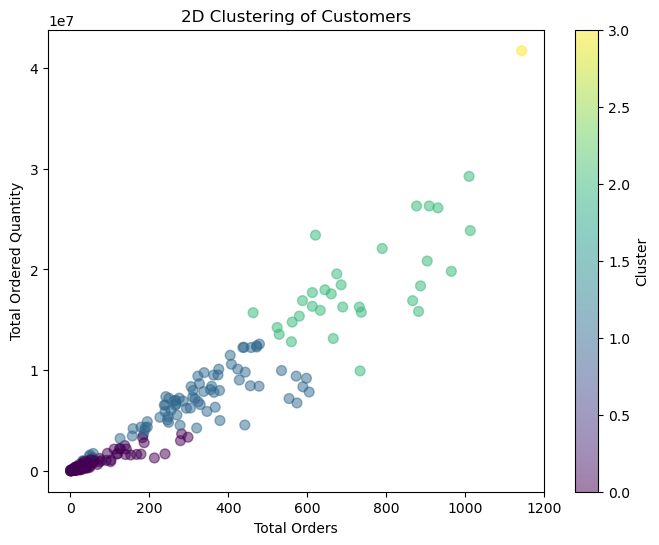

Data saved to customer_classification_4_clusters.xlsx successfully.


C:\Users\user\AppData\Local\Temp\ipykernel_50316\3457821362.py:110: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  classified_data.to_excel("customer_classification_4_clusters.xlsx", index=False)


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def connect_to_db():
    try:
        conn = pyodbc.connect('DRIVER={SQL Server};SERVER=LAPTOP-HED7JE2F;DATABASE=PGS_STAGE_DW;UID=sa;PWD=sa@123@123')
        return conn
    except Exception as e:
        print(f"Failed to connect to database: {e}")
        return None

def fetch_data():
    query = """
    SELECT
        c.CUSTOMER_NUMBER,
        COUNT(DISTINCT o.PK_ORDERS) AS Total_Orders,
        ABS(SUM(CAST(s.ORDERED_QUANTITY AS BIGINT))) AS Total_Ordered_Quantity,
        MIN(o.START_LOAD_TIME) AS First_Order_Date,
        MAX(o.START_LOAD_TIME) AS Last_Order_Date
    FROM
        DIM_CUSTOMER c
    JOIN
        FACT_SALES s ON c.PK_CUSTOMER = s.FK_CUSTOMER
    JOIN
        DIM_ORDERS o ON s.FK_ORDERS = o.PK_ORDERS
    WHERE
        c.CUSTOMER_NUMBER != 111
    GROUP BY
        c.CUSTOMER_NUMBER
    """
    conn = connect_to_db()
    if conn is None:
        return None

    try:
        data = pd.read_sql(query, conn)
        return data
    except Exception as e:
        print(f"Failed to execute query: {e}")
        return None
    finally:
        conn.close()

def calculate_additional_metrics(data):
    data['Avg_Quantity_Per_Order'] = data['Total_Ordered_Quantity'] / data['Total_Orders']
    data['Order_Duration_Days'] = (data['Last_Order_Date'] - data['First_Order_Date']).dt.days
    data['Order_Frequency'] = data['Total_Orders'] / data['Order_Duration_Days'].replace(0, 1)
    return data

def clean_data(data):
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.fillna(data.mean(), inplace=True)
    return data

def perform_classification(data):
    # Identify the customer with the maximum Total Orders and Total Ordered Quantity
    max_customer = data.loc[data[['Total_Orders', 'Total_Ordered_Quantity']].idxmax().max()]
   
    # Remove this customer from clustering data
    data_for_clustering = data.drop(max_customer.name)
   
    # Apply clustering to the remaining customers
    imputer = SimpleImputer(strategy='mean')
    data_filled = imputer.fit_transform(data_for_clustering[['Total_Orders', 'Total_Ordered_Quantity', 'Avg_Quantity_Per_Order', 'Order_Frequency']])
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_filled)
   
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(data_scaled)
   
    data_for_clustering['Cluster'] = clusters
   
    # Assign a unique cluster to the max_customer
    max_customer['Cluster'] = 3
   
    # Combine back the max_customer with the clustered data
    classified_data = pd.concat([data_for_clustering, pd.DataFrame([max_customer])])
   
    return classified_data, imputer, scaler, kmeans

def visualize_clusters(data):
    plt.figure(figsize=(8, 6))
    plt.scatter(data['Total_Orders'], data['Total_Ordered_Quantity'], c=data['Cluster'], cmap='viridis', s=50, alpha=0.5)
    plt.title('2D Clustering of Customers')
    plt.xlabel('Total Orders')
    plt.ylabel('Total Ordered Quantity')
    plt.colorbar(label='Cluster')
    plt.show()

def main():
    data = fetch_data()
    if data is not None:
        data = calculate_additional_metrics(data)
        data = clean_data(data)
        classified_data, imputer, scaler, kmeans = perform_classification(data)
       
        classified_data['Supplier Type'] = classified_data['Cluster'].map({
            0: 'Regular Suppliers',
            1: 'Occasional Suppliers',
            2: 'Premium Suppliers',
            3: 'Top Customer'
        })
       
        visualize_clusters(classified_data)
        classified_data.to_excel("customer_classification_4_clusters.xlsx", index=False)
        print("Data saved to customer_classification_4_clusters.xlsx successfully.")

if __name__ == "__main__":
    main()